# Indago PT: detecção de reviews falsas/sintéticas em português brasileiro

Este notebook é o artefato principal de código-fonte do experimento. Ele contém todo o pipeline executável de ponta a ponta e não importa módulos da pasta `src/`.

O problema é classificar uma review individual em português brasileiro como `0` falsa/sintética ou `1` genuína. O dataset é o Fake Reviews PT-BR Dataset, derivado de reviews genuínas da Olist e reviews falsas/sintéticas geradas por GPT-2.

O modelo principal é uma CNN 1D em PyTorch. Os baselines são TF-IDF + Regressão Logística e TF-IDF + SVM Linear. As métricas são acurácia, precisão/recall/F1 da classe falsa (`label 0`), F1 macro, AUC-ROC da classe 0, matriz de confusão e relatório de classificação.


## Instalação e dependências

Instale as dependências com `python -m pip install -r requirements.txt` antes de executar. O notebook não instala pacotes automaticamente.

```python
!pip install pandas numpy scikit-learn matplotlib seaborn torch joblib jupyter
```


In [142]:
%matplotlib inline
import io
import json
import random
import re
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Optional

from IPython.display import display, Markdown

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

In [143]:
import sys
import platform
import torch

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("Torch version:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("CUDA current device:", torch.cuda.current_device())
    print("CUDA device name:", torch.cuda.get_device_name(0))
else:
    print("CUDA device name: CPU fallback")


Python executable: c:\Users\Altair\Documents\Working\Development\Indago\.venv\Scripts\python.exe
Python version: 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
Torch version: 2.11.0+cu128
Torch CUDA build: 12.8
CUDA available: True
CUDA device count: 1
CUDA current device: 0
CUDA device name: NVIDIA GeForce RTX 3060 Ti


## Configuração global

Use `USE_SMOKE_TEST = False` para validar rapidamente com `tests/fixtures/smoke_reviews.csv`. O padrão `False` executa o dataset real em `data/raw/true_fake_dataset_top15.csv` e salva em `outputs/`.


In [144]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

# Use True para teste rápido com dataset sintético pequeno.
# Use False para rodar o dataset real.
USE_SMOKE_TEST = False

RANDOM_STATE = 13
VOCAB_SIZE = 30000
MAX_LEN = 256
EMBEDDING_DIM = 128
FILTERS = 256
KERNEL_SIZE = 7
DROPOUT = 0.5
LR = 0.001
BATCH_SIZE = 128
EPOCHS = 50
PATIENCE = 3
TFIDF_MAX_FEATURES = 30000
TFIDF_MIN_DF = 2
TFIDF_NGRAM_MAX = 2
ERROR_SAMPLES = 10

DATASET_URL = 'https://raw.githubusercontent.com/cristianomg10/fake-reviews-ptbr-dataset/main/true_fake_dataset_top15.csv'
DATASET_FILENAME = 'true_fake_dataset_top15.csv'
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / DATASET_FILENAME
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

if USE_SMOKE_TEST:
    DATA_PATH = PROJECT_ROOT / 'tests' / 'fixtures' / 'smoke_reviews.csv'
    OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'smoke'
    EPOCHS = 1
    BATCH_SIZE = 4
    VOCAB_SIZE = 100
    MAX_LEN = 32
    EMBEDDING_DIM = 16
    FILTERS = 16
    PATIENCE = 1
    TFIDF_MAX_FEATURES = 200
    TFIDF_MIN_DF = 1

FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR = OUTPUT_DIR / 'tables'
MODELS_DIR = OUTPUT_DIR / 'models'
CNN_MODEL_PATH = MODELS_DIR / 'cnn1d.pt'

CANONICAL_TEXT = 'text'
CANONICAL_CATEGORY = 'category'
CANONICAL_LABEL = 'label'
CLASS_LABELS = ['falsa/sintetica (0)', 'genuina (1)']

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo usado: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU usada: {torch.cuda.get_device_name(0)}')


def save_json(data: dict[str, Any], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding='utf-8')

print(f'Project root: {PROJECT_ROOT}')
print(f'Data path: {DATA_PATH}')
print(f'Output dir: {OUTPUT_DIR}')
print(f'Device: {DEVICE}')

Dispositivo usado: cuda
GPU usada: NVIDIA GeForce RTX 3060 Ti
Project root: c:\Users\Altair\Documents\Working\Development\Indago
Data path: c:\Users\Altair\Documents\Working\Development\Indago\data\raw\true_fake_dataset_top15.csv
Output dir: c:\Users\Altair\Documents\Working\Development\Indago\outputs
Device: cuda


## Dataset

O arquivo esperado é `data/raw/true_fake_dataset_top15.csv`. Se ele não existir, baixe o CSV em:

https://raw.githubusercontent.com/cristianomg10/fake-reviews-ptbr-dataset/main/true_fake_dataset_top15.csv

Depois salve em `data/raw/true_fake_dataset_top15.csv` e execute novamente.


In [145]:
def check_dataset_exists(path: Path) -> None:
    if path.exists():
        print(f'Dataset encontrado: {path}')
        return
    raise FileNotFoundError(f'Dataset não encontrado.\n'\
                            f'Link: {DATASET_URL}\n'\
                            f'Caminho esperado: {path}\n'\
                            f'Comando PowerShell para baixar:\n'\
                            f'Invoke-WebRequest -Uri "{DATASET_URL}" -OutFile "{path}"')

def ensure_directories() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    TABLES_DIR.mkdir(parents=True, exist_ok=True)
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

check_dataset_exists(DATA_PATH)
ensure_directories()

Dataset encontrado: c:\Users\Altair\Documents\Working\Development\Indago\data\raw\true_fake_dataset_top15.csv


## Carregamento e pré-processamento

As colunas canônicas são detectadas, validadas e salvas em `outputs/tables/column_mapping.json`. A limpeza é mínima: remove textos vazios e normaliza espaços/quebras de linha, preservando acentos, pontuação, stopwords e conteúdo textual.


In [146]:
@dataclass(frozen=True, slots=True)
class ColumnMapping:
    text: str
    category: str
    label: str

    def to_dict(self) -> dict[str, str]:
        return asdict(self)

@dataclass(frozen=True, slots=True)
class LoadedDataset:
    frame: pd.DataFrame
    mapping: ColumnMapping

def _normalize_name(name: str) -> str:
    name = str(name).strip().lower()
    return re.sub(r"[^a-z0-9]+", "_", name).strip("_")

def _find_column(columns: list[str], candidates: tuple[str, ...]) -> Optional[str]:
    normalized = {_normalize_name(col): col for col in columns}
    for candidate in candidates:
        key = _normalize_name(candidate)
        if key in normalized:
            return normalized[key]
    for col in columns:
        key = _normalize_name(col)
        if any(candidate in key for candidate in candidates):
            return col
    return None

def infer_columns(df: pd.DataFrame) -> ColumnMapping:
    columns = list(df.columns)
    text = _find_column(columns, ("review_comment_message", "review_text", "review", "text", "texto", "comentario", "mensagem"))
    category = _find_column(columns, ("product_category_name", "category", "categoria", "product_category", "classe_produto"))
    label = _find_column(columns, ("label", "target", "class", "classe", "rotulo", "fake", "is_fake"))

    missing = [name for name, value in (("text", text), ("category", category), ("label", label)) if value is None]
    if missing:
        raise ValueError(f"Could not infer required columns {missing}. Available columns: {columns}. Rename the CSV columns.")
    return ColumnMapping(text=text, category=category, label=label)

def _read_csv(path: Path) -> pd.DataFrame:
    attempts = (
        {"engine": "python"},
        {"engine": "python", "on_bad_lines": "warn"},
        {"engine": "python", "sep": ","},
    )
    last_error: Optional[Exception] = None
    for kwargs in attempts:
        try:
            df = pd.read_csv(path, **kwargs)
            if df.shape[1] >= 3:
                return df
        except Exception as exc:
            last_error = exc

    try:
        text = path.read_text(encoding="utf-8", errors="replace")
        normalized = text.replace("\r\n", "\n").replace("\r", "\n")
        return pd.read_csv(io.StringIO(normalized), engine="python")
    except Exception as exc:
        if last_error is not None:
            raise ValueError(f"Could not read CSV. Last parser error: {last_error}") from exc
        raise

def _coerce_labels(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        labels = pd.to_numeric(series, errors="coerce")
    else:
        mapping = {"0": 0, "fake": 0, "false": 0, "falsa": 0, "sintetica": 0, "synthetic": 0, "1": 1, "true": 1, "real": 1, "genuine": 1, "genuina": 1, "verdadeira": 1}
        labels = series.astype(str).str.strip().str.lower().map(mapping)

    if labels.isna().any():
        bad_values = series[labels.isna()].drop_duplicates().head(10).tolist()
        raise ValueError(f"Could not map label values to 0/1. Examples: {bad_values}")

    labels = labels.astype(int)
    values = set(labels.unique().tolist())
    if not values.issubset({0, 1}):
        raise ValueError(f"Labels must be binary 0/1. Found values: {sorted(values)}")
    return labels

def load_dataset(path: str | Path) -> LoadedDataset:
    dataset_path = Path(path)
    if not dataset_path.exists():
        raise FileNotFoundError(
            f"Dataset not found at: {dataset_path}\n"
            f"Download {DATASET_FILENAME} from {DATASET_URL} and place it at:\n"
            f"  data/raw/{DATASET_FILENAME}\n"
            "Then run the experiment again. No metrics were generated."
        )

    raw = _read_csv(dataset_path)
    mapping = infer_columns(raw)

    frame = pd.DataFrame({
        CANONICAL_TEXT: raw[mapping.text],
        CANONICAL_CATEGORY: raw[mapping.category],
        CANONICAL_LABEL: _coerce_labels(raw[mapping.label]),
    })
    return LoadedDataset(frame=frame, mapping=mapping)

SPACE_RE = re.compile(r"\s+")

def normalize_text(value: object) -> str:
    if pd.isna(value):
        return ""
    text = str(value).replace("\r", " ").replace("\n", " ").replace("\t", " ")
    return SPACE_RE.sub(" ", text).strip()

def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    cleaned[CANONICAL_TEXT] = cleaned[CANONICAL_TEXT].map(normalize_text)
    cleaned[CANONICAL_CATEGORY] = cleaned[CANONICAL_CATEGORY].fillna("unknown").astype(str).map(normalize_text)
    cleaned = cleaned[cleaned[CANONICAL_TEXT].str.len() > 0].copy()
    cleaned[CANONICAL_LABEL] = cleaned[CANONICAL_LABEL].astype(int)
    cleaned["char_len"] = cleaned[CANONICAL_TEXT].str.len()
    cleaned["token_len"] = cleaned[CANONICAL_TEXT].str.split().str.len()
    return cleaned.reset_index(drop=True)

## Análise exploratória

Gera contagens, distribuição por classe/categoria, tamanhos dos textos, valores ausentes, duplicatas, exemplos por classe e gráficos em `outputs/`.


In [147]:
def _save_barplot(table: pd.DataFrame, x: str, y: str, title: str, output_path: Path) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=table, x=x, y=y, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()
    plt.close(fig)

def run_eda(df: pd.DataFrame, tables_dir: Path, figures_dir: Path, random_state: int = 42) -> None:
    tables_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    summary = {
        "total_samples_after_cleaning": int(len(df)),
        "missing_text": int(df[CANONICAL_TEXT].isna().sum()),
        "missing_category": int(df[CANONICAL_CATEGORY].isna().sum()),
        "missing_label": int(df[CANONICAL_LABEL].isna().sum()),
        "duplicated_rows": int(df.duplicated().sum()),
        "duplicated_texts": int(df[CANONICAL_TEXT].duplicated().sum()),
        "char_len_min": int(df["char_len"].min()),
        "char_len_mean": float(df["char_len"].mean()),
        "char_len_median": float(df["char_len"].median()),
        "char_len_max": int(df["char_len"].max()),
        "token_len_min": int(df["token_len"].min()),
        "token_len_mean": float(df["token_len"].mean()),
        "token_len_median": float(df["token_len"].median()),
        "token_len_max": int(df["token_len"].max()),
    }
    save_json(summary, tables_dir / "eda_summary.json")

    missing = df.isna().sum().reset_index()
    missing.columns = ["column", "missing_count"]
    missing.to_csv(tables_dir / "missing_values.csv", index=False)

    class_dist = df[CANONICAL_LABEL].value_counts().sort_index().rename_axis(CANONICAL_LABEL).reset_index(name="count")
    class_dist["class_name"] = class_dist[CANONICAL_LABEL].map({0: "falsa/sintetica", 1: "genuina"})
    class_dist.to_csv(tables_dir / "class_distribution.csv", index=False)
    _save_barplot(class_dist, "class_name", "count", "Distribuicao por classe", figures_dir / "class_distribution.png")

    category_dist = df[CANONICAL_CATEGORY].value_counts().rename_axis(CANONICAL_CATEGORY).reset_index(name="count")
    category_dist.to_csv(tables_dir / "category_distribution.csv", index=False)
    _save_barplot(category_dist, CANONICAL_CATEGORY, "count", "Distribuicao por categoria", figures_dir / "category_distribution.png")

    length_summary = df[["char_len", "token_len"]].describe().T.reset_index().rename(columns={"index": "metric"})
    length_summary.to_csv(tables_dir / "review_length_summary.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(df["char_len"], bins=40, kde=False, ax=ax)
    ax.set_title("Distribuicao do tamanho das reviews em caracteres")
    ax.set_xlabel("Caracteres")
    fig.tight_layout()
    fig.savefig(figures_dir / "review_char_length_hist.png", dpi=160)
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(df["token_len"], bins=40, kde=False, ax=ax)
    ax.set_title("Distribuicao do tamanho das reviews em tokens")
    ax.set_xlabel("Tokens por espaco")
    fig.tight_layout()
    fig.savefig(figures_dir / "review_token_length_hist.png", dpi=160)
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(data=df, x=CANONICAL_LABEL, y="token_len", ax=ax)
    ax.set_title("Tamanho das reviews por classe")
    ax.set_xlabel("Classe")
    ax.set_ylabel("Tokens")
    fig.tight_layout()
    fig.savefig(figures_dir / "review_token_length_by_class.png", dpi=160)
    plt.show()
    plt.close(fig)

    examples = df.groupby(CANONICAL_LABEL, group_keys=False).sample(n=min(5, df[CANONICAL_LABEL].value_counts().min()), random_state=random_state)[[CANONICAL_LABEL, CANONICAL_CATEGORY, CANONICAL_TEXT]]
    examples.to_csv(tables_dir / "examples_by_class.csv", index=False)

## Discussão sobre duplicatas

Na execução principal documentada, a EDA encontrou **683 linhas duplicadas** e **1.537 textos duplicados**. O protocolo quantifica, mas **não remove duplicatas antes do split**. Isso é uma ameaça à validade por possível data leakage, pois textos iguais ou semelhantes podem aparecer em treino, validação e teste. A célula de execução imprime os valores da execução atual.


## Split treino/validação/teste

A divisão usa 70/15/15 e `random_state=42`. A estratificação usa categoria + label quando possível; caso contrário, usa apenas label. O notebook salva `outputs/tables/split_summary.csv` e não recria previews grandes.


In [148]:
def _stratify_key(df: pd.DataFrame) -> pd.Series:
    key = df[CANONICAL_CATEGORY].astype(str) + '__' + df[CANONICAL_LABEL].astype(str)
    return key if key.value_counts().min() >= 2 else df[CANONICAL_LABEL]

def split_dataset(df: pd.DataFrame, random_state: int = RANDOM_STATE, train_size: float = 0.70, val_size: float = 0.15, test_size: float = 0.15) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if abs((train_size + val_size + test_size) - 1.0) > 1e-8:
        raise ValueError('train_size + val_size + test_size must sum to 1.0')
    temp_size = val_size + test_size
    try:
        train_df, temp_df = train_test_split(df, train_size=train_size, random_state=random_state, stratify=_stratify_key(df))
    except ValueError:
        train_df, temp_df = train_test_split(df, train_size=train_size, random_state=random_state, stratify=df[CANONICAL_LABEL])
    
    relative_test_size = test_size / temp_size
    try:
        val_df, test_df = train_test_split(temp_df, test_size=relative_test_size, random_state=random_state, stratify=_stratify_key(temp_df))
    except ValueError:
        val_df, test_df = train_test_split(temp_df, test_size=relative_test_size, random_state=random_state, stratify=temp_df[CANONICAL_LABEL])
    
    train_df, val_df, test_df = train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)
    
    split_summary = pd.DataFrame([
        {'split': 'train', 'samples': len(train_df), 'label_0': int((train_df[CANONICAL_LABEL] == 0).sum()), 'label_1': int((train_df[CANONICAL_LABEL] == 1).sum())},
        {'split': 'validation', 'samples': len(val_df), 'label_0': int((val_df[CANONICAL_LABEL] == 0).sum()), 'label_1': int((val_df[CANONICAL_LABEL] == 1).sum())},
        {'split': 'test', 'samples': len(test_df), 'label_0': int((test_df[CANONICAL_LABEL] == 0).sum()), 'label_1': int((test_df[CANONICAL_LABEL] == 1).sum())},
    ])
    split_summary.to_csv(TABLES_DIR / 'split_summary.csv', index=False)
    display(split_summary)
    return train_df, val_df, test_df

## Métricas e funções auxiliares


In [149]:
def compute_binary_metrics(y_true: np.ndarray | list[int], y_pred: np.ndarray | list[int], score_label_0: np.ndarray | list[float], model_name: str) -> dict[str, float | str]:
    y_true_arr = np.asarray(y_true).astype(int)
    y_pred_arr = np.asarray(y_pred).astype(int)
    score_arr = np.asarray(score_label_0, dtype=float)
    y_true_fake = (y_true_arr == 0).astype(int)

    try:
        auc = float(roc_auc_score(y_true_fake, score_arr))
    except ValueError:
        auc = float("nan")

    return {
        "model": model_name,
        "accuracy": float(accuracy_score(y_true_arr, y_pred_arr)),
        "precision_fake_label_0": float(precision_score(y_true_arr, y_pred_arr, pos_label=0, zero_division=0)),
        "recall_fake_label_0": float(recall_score(y_true_arr, y_pred_arr, pos_label=0, zero_division=0)),
        "f1_fake_label_0": float(f1_score(y_true_arr, y_pred_arr, pos_label=0, zero_division=0)),
        "f1_macro": float(f1_score(y_true_arr, y_pred_arr, average="macro", zero_division=0)),
        "auc_roc_fake_label_0": auc,
    }

def save_confusion_matrix(y_true: np.ndarray | list[int], y_pred: np.ndarray | list[int], model_name: str, output_path: Path) -> np.ndarray:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
    ax.set_title(f"Matriz de confusao - {model_name}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()
    plt.close(fig)
    return cm

def build_error_analysis(test_df: pd.DataFrame, y_pred: np.ndarray | list[int], score_label_0: np.ndarray | list[float], n_samples: int = 10) -> pd.DataFrame:
    result = test_df[[CANONICAL_TEXT, CANONICAL_CATEGORY, CANONICAL_LABEL]].copy()
    result["prediction"] = np.asarray(y_pred).astype(int)
    result["prob_or_score_fake_label_0"] = np.asarray(score_label_0, dtype=float)

    fp = result[(result[CANONICAL_LABEL] == 1) & (result["prediction"] == 0)].copy()
    fp["error_type"] = "false_positive_genuine_predicted_fake"

    fn = result[(result[CANONICAL_LABEL] == 0) & (result["prediction"] == 1)].copy()
    fn["error_type"] = "false_negative_fake_predicted_genuine"

    cols = ["error_type", CANONICAL_CATEGORY, CANONICAL_LABEL, "prediction", "prob_or_score_fake_label_0", CANONICAL_TEXT]
    return pd.concat([fp.head(n_samples), fn.head(n_samples)], axis=0)[cols]

def save_model_comparison(metrics: list[dict[str, float | str]], tables_dir: Path) -> pd.DataFrame:
    tables_dir.mkdir(parents=True, exist_ok=True)
    table = pd.DataFrame(metrics)
    table.to_csv(tables_dir / "model_comparison.csv", index=False)
    return table

## Baselines TF-IDF


In [150]:
def build_tfidf_pipeline(classifier, max_features: int, min_df: int, ngram_max: int) -> Pipeline:
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    max_features=max_features,
                    ngram_range=(1, ngram_max),
                    lowercase=True,
                    min_df=min_df,
                    max_df=0.95,
                ),
            ),
            ("classifier", classifier),
        ]
    )

def _score_label_0_from_logistic(pipeline: Pipeline, texts: pd.Series) -> np.ndarray:
    classifier = pipeline.named_steps["classifier"]
    classes = list(classifier.classes_)
    label_0_index = classes.index(0)
    return pipeline.predict_proba(texts)[:, label_0_index]

def _score_label_0_from_svm(pipeline: Pipeline, texts: pd.Series) -> np.ndarray:
    classifier = pipeline.named_steps["classifier"]
    decision = pipeline.decision_function(texts)
    classes = list(classifier.classes_)
    if len(classes) != 2:
        raise ValueError(f"Expected binary SVM classes, got: {classes}")
    return -decision if classes[1] == 1 else decision

def train_and_evaluate_baselines(train_df: pd.DataFrame, test_df: pd.DataFrame, models_dir: Path, figures_dir: Path, max_features: int, min_df: int, ngram_max: int, random_state: int) -> list[dict[str, float | str]]:
    models_dir.mkdir(parents=True, exist_ok=True)
    metrics: list[dict[str, float | str]] = []
    x_train, y_train = train_df[CANONICAL_TEXT], train_df[CANONICAL_LABEL]
    x_test, y_test = test_df[CANONICAL_TEXT], test_df[CANONICAL_LABEL].to_numpy()

    logistic = build_tfidf_pipeline(
        LogisticRegression(max_iter=1000, random_state=random_state),
        max_features,
        min_df,
        ngram_max,
    )
    logistic.fit(x_train, y_train)
    logistic_pred = logistic.predict(x_test)
    metrics.append(compute_binary_metrics(y_test, logistic_pred, _score_label_0_from_logistic(logistic, x_test), "tfidf_logistic_regression"))
    save_confusion_matrix(y_test, logistic_pred, "TF-IDF + Regressao Logistica", figures_dir / "confusion_matrix_logistic_regression.png")
    
    logistic_report = pd.DataFrame(classification_report(y_test, logistic_pred, labels=[0, 1], target_names=CLASS_LABELS, output_dict=True, zero_division=0)).T.reset_index().rename(columns={"index": "label"})
    logistic_report.to_csv(TABLES_DIR / "classification_report_logistic_regression.csv", index=False)
    joblib.dump(logistic, models_dir / "tfidf_logistic_regression.joblib")

    svm = build_tfidf_pipeline(
        LinearSVC(),
        max_features,
        min_df,
        ngram_max,
    )
    svm.fit(x_train, y_train)
    svm_pred = svm.predict(x_test)
    metrics.append(compute_binary_metrics(y_test, svm_pred, _score_label_0_from_svm(svm, x_test), "tfidf_linear_svm"))
    save_confusion_matrix(y_test, svm_pred, "TF-IDF + SVM Linear", figures_dir / "confusion_matrix_linear_svm.png")
    
    svm_report = pd.DataFrame(classification_report(y_test, svm_pred, labels=[0, 1], target_names=CLASS_LABELS, output_dict=True, zero_division=0)).T.reset_index().rename(columns={"index": "label"})
    svm_report.to_csv(TABLES_DIR / "classification_report_linear_svm.csv", index=False)
    joblib.dump(svm, models_dir / "tfidf_linear_svm.joblib")

    return metrics

## CNN 1D


In [151]:
TOKEN_RE = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"

@dataclass(frozen=True, slots=True)
class CNNHyperparameters:
    vocab_size: int
    max_len: int
    embedding_dim: int
    filters: int
    kernel_size: int
    dropout: float
    learning_rate: float
    batch_size: int
    epochs: int
    patience: int

def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(str(text).lower())

def build_vocab(texts: pd.Series, vocab_size: int) -> dict[str, int]:
    counter: Counter[str] = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for token, _ in counter.most_common(max(0, vocab_size - len(vocab))):
        if token not in vocab:
            vocab[token] = len(vocab)
    return vocab

def encode_text(text: str, vocab: dict[str, int], max_len: int) -> list[int]:
    ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokenize(text)][:max_len]
    if len(ids) < max_len:
        ids.extend([vocab[PAD_TOKEN]] * (max_len - len(ids)))
    return ids

class ReviewDataset(Dataset):
    def __init__(self, texts: pd.Series | list[str], labels: pd.Series | list[int] | None, vocab: dict[str, int], max_len: int) -> None:
        self.inputs = torch.tensor([encode_text(text, vocab, max_len) for text in texts], dtype=torch.long)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels, dtype=np.float32), dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.inputs)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor] | torch.Tensor:
        return self.inputs[index] if self.labels is None else (self.inputs[index], self.labels[index])

class CNN1DClassifier(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, filters: int, kernel_size: int, dropout: float) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(in_channels=embedding_dim, out_channels=filters, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(filters, 1)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        channels_first = embedded.transpose(1, 2)
        features = self.relu(self.conv(channels_first))
        pooled = torch.max(features, dim=2).values
        dropped = self.dropout(pooled)
        return self.classifier(dropped).squeeze(1)

def _accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> float:
    return float(((torch.sigmoid(logits) >= 0.5).float() == labels).float().mean().item())

def _run_epoch(model: CNN1DClassifier, loader: DataLoader, criterion: nn.Module, device: torch.device, optimizer: Optional[torch.optim.Optimizer] = None) -> tuple[float, float]:
    is_training = optimizer is not None
    model.train(is_training)
    losses, accuracies = [], []

    for input_ids, labels in loader:
        input_ids, labels = input_ids.to(device), labels.to(device)

        with torch.set_grad_enabled(is_training):
            logits = model(input_ids)
            loss = criterion(logits, labels)
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        batch_size = labels.shape[0]
        losses.append(float(loss.item()) * batch_size)
        accuracies.append(_accuracy_from_logits(logits.detach(), labels) * batch_size)

    total = len(loader.dataset)
    return sum(losses) / total, sum(accuracies) / total

def train_cnn(train_df: pd.DataFrame, val_df: pd.DataFrame, hparams: CNNHyperparameters, model_path: Path, random_state: int = 42, device: Optional[torch.device] = None) -> tuple[CNN1DClassifier, dict[str, int], pd.DataFrame]:
    if hparams.max_len < hparams.kernel_size:
        raise ValueError("max_len must be greater than or equal to kernel_size.")

    set_seed(random_state)
    device = device or DEVICE
    print("Treinamento CNN 1D")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("Aviso: treinamento em CPU")
    vocab = build_vocab(train_df[CANONICAL_TEXT], hparams.vocab_size)
    model = CNN1DClassifier(hparams.vocab_size, hparams.embedding_dim, hparams.filters, hparams.kernel_size, hparams.dropout).to(device)

    train_loader = DataLoader(ReviewDataset(train_df[CANONICAL_TEXT], train_df[CANONICAL_LABEL], vocab, hparams.max_len), batch_size=hparams.batch_size, shuffle=True)
    val_loader = DataLoader(ReviewDataset(val_df[CANONICAL_TEXT], val_df[CANONICAL_LABEL], vocab, hparams.max_len), batch_size=hparams.batch_size, shuffle=False)

    criterion, optimizer = nn.BCEWithLogitsLoss(), torch.optim.Adam(model.parameters(), lr=hparams.learning_rate)
    best_val_loss, best_state, wait, history = float("inf"), None, 0, []

    for epoch in range(1, hparams.epochs + 1):
        train_loss, train_accuracy = _run_epoch(model, train_loader, criterion, device, optimizer)
        with torch.no_grad():
            val_loss, val_accuracy = _run_epoch(model, val_loader, criterion, device)

        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "train_accuracy": train_accuracy, "val_accuracy": val_accuracy})

        if val_loss < best_val_loss - 1e-6:
            best_val_loss, wait = val_loss, 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            model_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save({"model_state_dict": best_state, "vocab": vocab, "hyperparameters": asdict(hparams), "best_val_loss": best_val_loss, "epoch": epoch}, model_path)
        else:
            wait += 1
            if wait >= hparams.patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, vocab, pd.DataFrame(history)

def predict_cnn(model: CNN1DClassifier, vocab: dict[str, int], texts: pd.Series | list[str], max_len: int, batch_size: int, device: Optional[torch.device] = None) -> dict[str, np.ndarray]:
    device = device or DEVICE
    print("Treinamento CNN 1D")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("Aviso: treinamento em CPU")
    model = model.to(device)
    model.eval()
    loader = DataLoader(ReviewDataset(texts, labels=None, vocab=vocab, max_len=max_len), batch_size=batch_size, shuffle=False)

    logits_batches = []
    with torch.no_grad():
        for input_ids in loader:
            logits_batches.append(model(input_ids.to(device)).detach().cpu().numpy())

    logits = np.concatenate(logits_batches)
    prob_label_1 = 1.0 / (1.0 + np.exp(-logits))
    return {"logits": logits, "prob_label_1": prob_label_1, "prob_label_0": 1.0 - prob_label_1, "pred_label": (prob_label_1 >= 0.5).astype(int)}

def save_training_history(history: pd.DataFrame, figures_dir: Path, tables_dir: Path) -> None:
    tables_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)
    history.to_csv(tables_dir / "cnn_training_history.csv", index=False)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(history["epoch"], history["train_loss"], label="train_loss")
    ax.plot(history["epoch"], history["val_loss"], label="val_loss")
    ax.set_title("CNN 1D - loss de treino e validacao")
    ax.legend()
    fig.tight_layout()
    fig.savefig(figures_dir / "cnn_loss_curve.png", dpi=160)
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(history["epoch"], history["train_accuracy"], label="train_accuracy")
    ax.plot(history["epoch"], history["val_accuracy"], label="val_accuracy")
    ax.set_title("CNN 1D - acuracia de treino e validacao")
    ax.legend()
    fig.tight_layout()
    fig.savefig(figures_dir / "cnn_accuracy_curve.png", dpi=160)
    plt.show()
    plt.close(fig)

## Execução do experimento

Executa carregamento, limpeza, EDA, split, baselines, CNN, avaliação, gráficos, tabelas e análise qualitativa de erros.


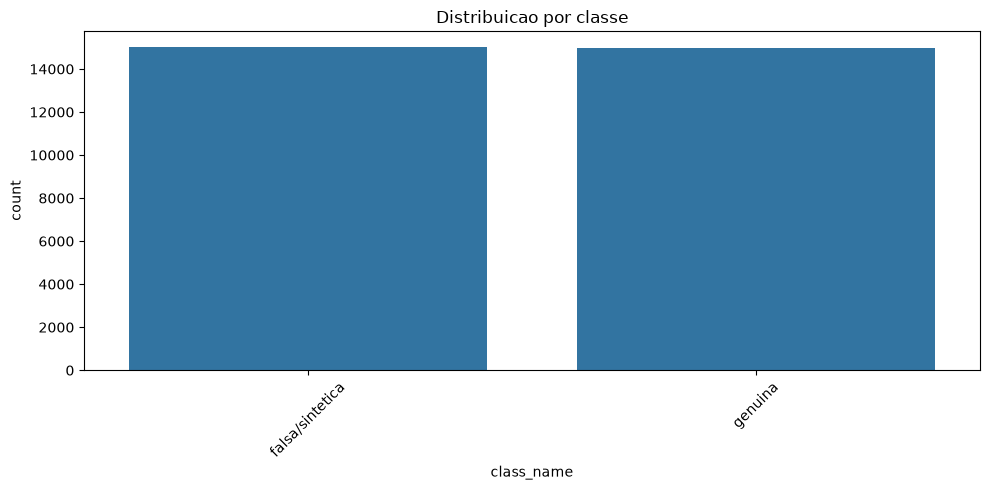

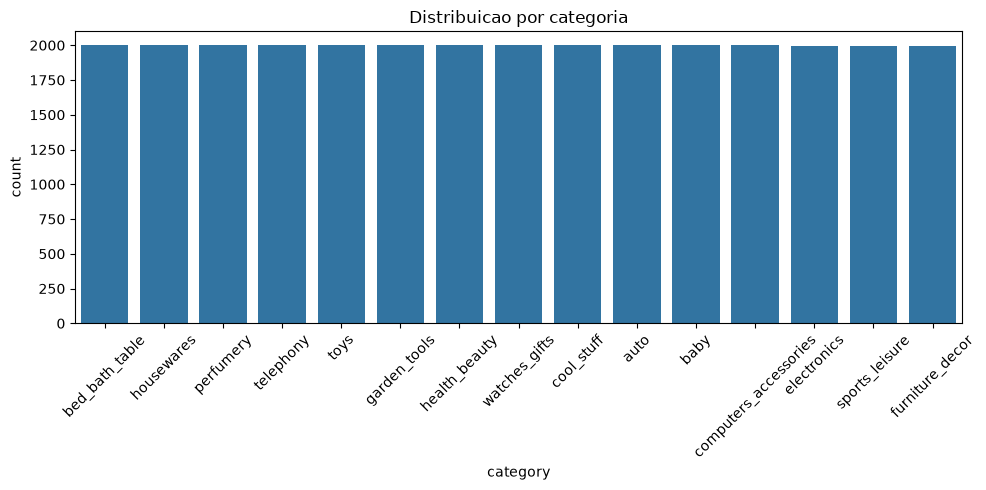

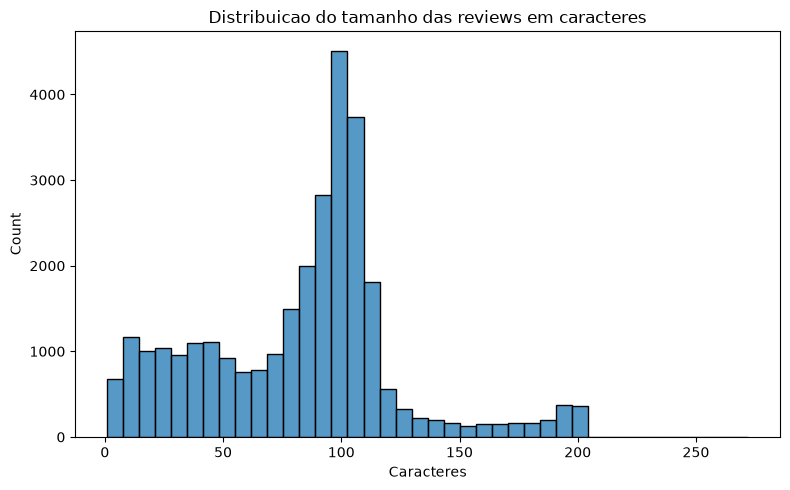

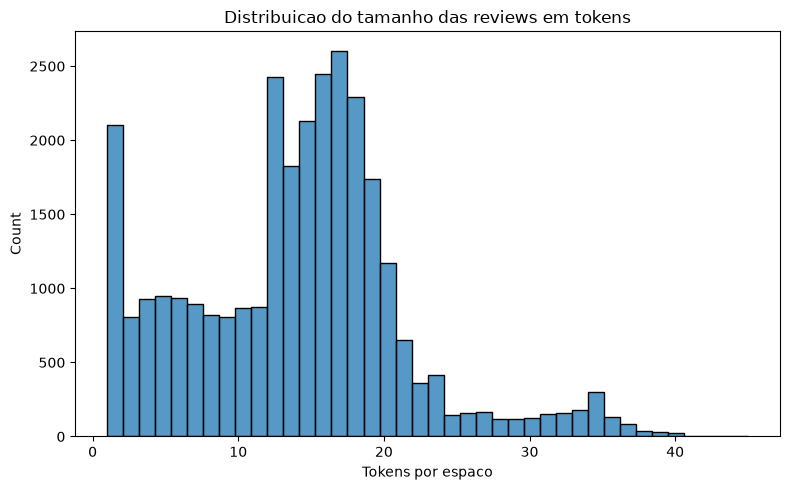

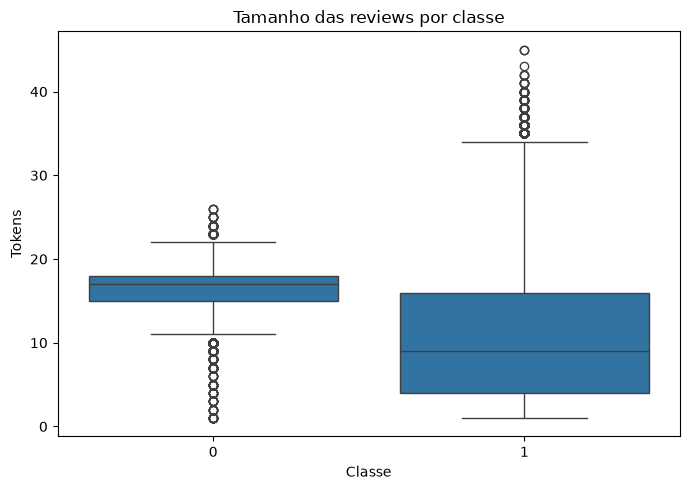

### Resumo da EDA

,0
total_samples_after_cleaning,29988.000000
missing_text,0.000000
missing_category,0.000000
missing_label,0.000000
duplicated_rows,683.000000
duplicated_texts,1537.000000
char_len_min,1.000000
char_len_mean,82.951080
char_len_median,92.000000
char_len_max,272.000000


,split,samples,label_0,label_1
0,train,20991,10500,10491
1,validation,4498,2250,2248
2,test,4499,2250,2249


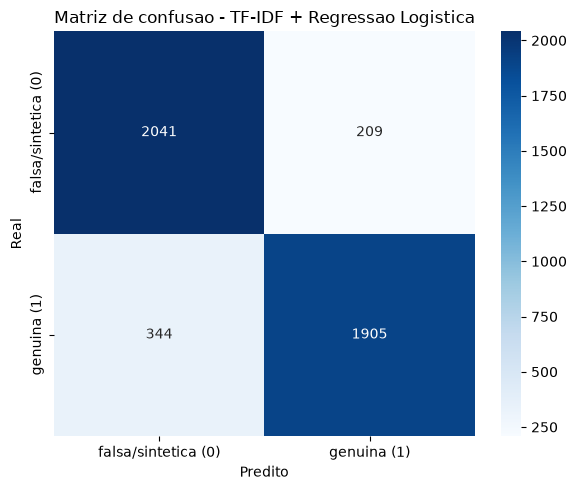

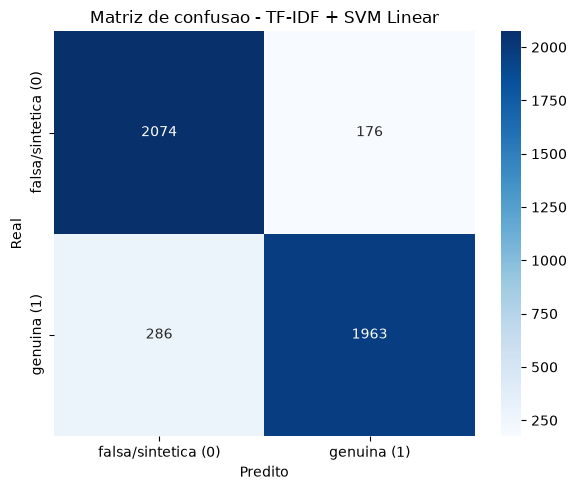

Treinamento CNN 1D
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


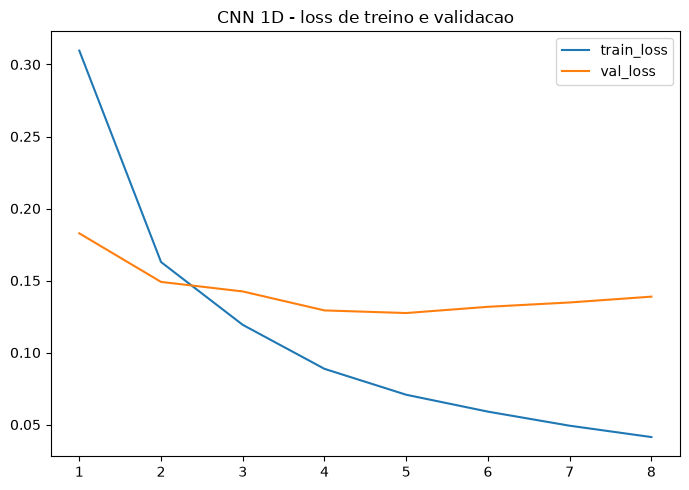

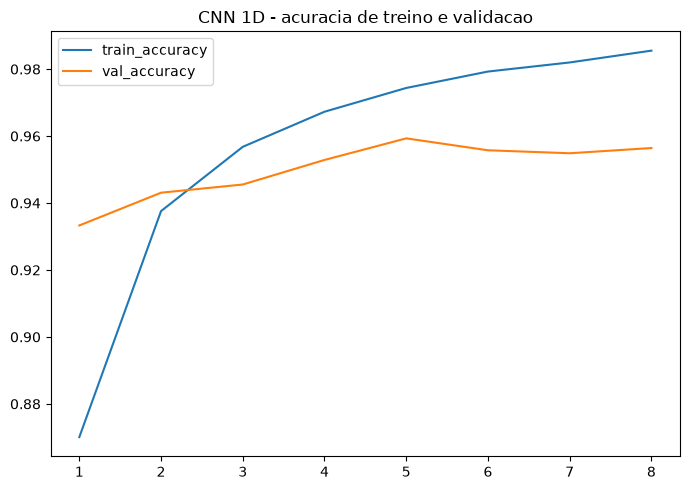

Treinamento CNN 1D
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


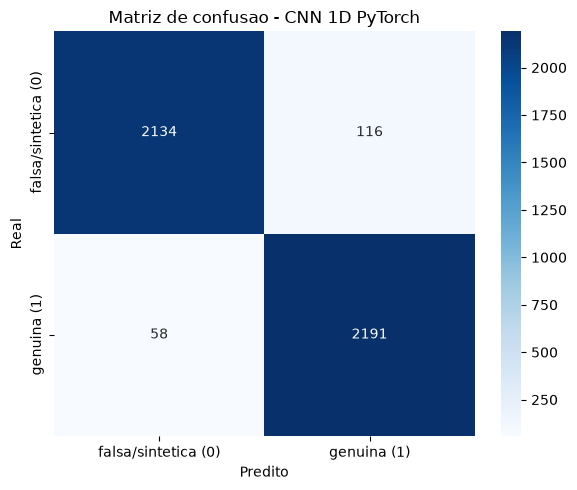

,model,accuracy,precision_fake_label_0,recall_fake_label_0,f1_fake_label_0,f1_macro,auc_roc_fake_label_0
0,tfidf_logistic_regression,0.877084,0.855765,0.907111,0.880690,0.876971,0.947198
1,tfidf_linear_svm,0.897311,0.878814,0.921778,0.899783,0.897248,0.960960
2,cnn1d_pytorch,0.961325,0.973540,0.948444,0.960828,0.961319,0.991352


Duplicatas observadas nesta execução:
Linhas duplicadas: 683
Textos duplicados: 1537
Essas duplicatas não foram removidas antes do split neste protocolo.


In [152]:
def run_full_experiment() -> dict:
    ensure_directories()
    
    import sys
    import sklearn
    environment_summary = {
        "python_version": sys.version.split()[0],
        "torch_version": torch.__version__,
        "sklearn_version": sklearn.__version__,
        "pandas_version": pd.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        "device_used": str(DEVICE),
    }
    save_json(environment_summary, TABLES_DIR / 'environment_summary.json')

    loaded = load_dataset(DATA_PATH)
    save_json(loaded.mapping.to_dict(), TABLES_DIR / 'column_mapping.json')
    df = clean_dataframe(loaded.frame)
    run_eda(df, TABLES_DIR, FIGURES_DIR, random_state=RANDOM_STATE)
    
    eda_summary = json.loads((TABLES_DIR / 'eda_summary.json').read_text(encoding='utf-8'))
    display(Markdown('### Resumo da EDA'))
    display(pd.DataFrame([eda_summary]).T)
    
    train_df, val_df, test_df = split_dataset(df, random_state=RANDOM_STATE)
    
    metrics = train_and_evaluate_baselines(train_df, test_df, MODELS_DIR, FIGURES_DIR, TFIDF_MAX_FEATURES, TFIDF_MIN_DF, TFIDF_NGRAM_MAX, RANDOM_STATE)
    
    hparams = CNNHyperparameters(VOCAB_SIZE, MAX_LEN, EMBEDDING_DIM, FILTERS, KERNEL_SIZE, DROPOUT, LR, BATCH_SIZE, EPOCHS, PATIENCE)
    model, vocab, history = train_cnn(train_df, val_df, hparams, CNN_MODEL_PATH, random_state=RANDOM_STATE, device=DEVICE)
    save_training_history(history, FIGURES_DIR, TABLES_DIR)
    
    predictions = predict_cnn(model, vocab, test_df[CANONICAL_TEXT], MAX_LEN, BATCH_SIZE, device=DEVICE)
    y_test = test_df[CANONICAL_LABEL].to_numpy()
    metrics.append(compute_binary_metrics(y_test, predictions['pred_label'], predictions['prob_label_0'], 'cnn1d_pytorch'))
    save_confusion_matrix(y_test, predictions['pred_label'], 'CNN 1D PyTorch', FIGURES_DIR / 'confusion_matrix_cnn1d.png')
    
    report_table = pd.DataFrame(classification_report(y_test, predictions['pred_label'], labels=[0, 1], target_names=CLASS_LABELS, output_dict=True, zero_division=0)).T.reset_index().rename(columns={'index': 'label'})
    report_table.to_csv(TABLES_DIR / 'classification_report_cnn1d.csv', index=False)
    
    errors = build_error_analysis(test_df, predictions['pred_label'], predictions['prob_label_0'], n_samples=ERROR_SAMPLES)
    errors.to_csv(TABLES_DIR / 'cnn_error_analysis.csv', index=False)
    
    comparison = save_model_comparison(metrics, TABLES_DIR)
    return {'eda_summary': eda_summary, 'comparison': comparison, 'errors': errors, 'history': history}

results = run_full_experiment()
comparison = results['comparison']
display(comparison)

print('Duplicatas observadas nesta execução:')
print(f"Linhas duplicadas: {results['eda_summary']['duplicated_rows']}")
print(f"Textos duplicados: {results['eda_summary']['duplicated_texts']}")
print('Essas duplicatas não foram removidas antes do split neste protocolo.')

## Análise qualitativa de erros

Mostra falsos positivos, falsos negativos, exemplos curtos e probabilidade/escore da classe falsa (`label 0`).


In [153]:
errors = results['errors'].copy()
errors['short_text'] = errors[CANONICAL_TEXT].str.slice(0, 180)
display(errors[['error_type', CANONICAL_CATEGORY, CANONICAL_LABEL, 'prediction', 'prob_or_score_fake_label_0', 'short_text']])

,error_type,category,label,prediction,prob_or_score_fake_label_0,short_text
137,false_positive_genuine_predicted_fake,housewares,1,0,0.880899,Muito ruim ... Comprei 02 Kits e foi entregue ...
145,false_positive_genuine_predicted_fake,perfumery,1,0,0.809110,Comprei dois kit para maquiagem chegou apenas ...
198,false_positive_genuine_predicted_fake,electronics,1,0,0.621168,"ainda não entregaram meu produto, apenas o out..."
340,false_positive_genuine_predicted_fake,cool_stuff,1,0,0.642083,JA LIGUEI PRA VOCES RECLAMANDO ESTOU AGUARDAND...
533,false_positive_genuine_predicted_fake,auto,1,0,0.675478,"O produto foi enviado rapidamente, e os correi..."
596,false_positive_genuine_predicted_fake,garden_tools,1,0,0.888704,"Não me enviaram o produto, alegando que não o ..."
688,false_positive_genuine_predicted_fake,garden_tools,1,0,0.782834,"Entrega super rápido, produto veio bem embalad..."
864,false_positive_genuine_predicted_fake,furniture_decor,1,0,0.902010,Fiquei muito feliz cm o produto e cm o prazo d...
923,false_positive_genuine_predicted_fake,sports_leisure,1,0,0.559043,O prazo de entrega era até dia 26/03 e até hoj...
965,false_positive_genuine_predicted_fake,bed_bath_table,1,0,0.683781,Chegou muito antes da previsao de entrega o pr...


## Resultados finais




In [154]:
display(comparison.sort_values('accuracy', ascending=False))

,model,accuracy,precision_fake_label_0,recall_fake_label_0,f1_fake_label_0,f1_macro,auc_roc_fake_label_0
2,cnn1d_pytorch,0.961325,0.973540,0.948444,0.960828,0.961319,0.991352
1,tfidf_linear_svm,0.897311,0.878814,0.921778,0.899783,0.897248,0.960960
0,tfidf_logistic_regression,0.877084,0.855765,0.907111,0.880690,0.876971,0.947198


## Conclusão

A CNN 1D superou os baselines TF-IDF neste protocolo. As conclusões são limitadas porque a classe falsa é sintética, gerada por GPT-2, e o projeto classifica reviews individuais, sem detectar astroturfing completo. A presença de duplicatas é ameaça à validade por possível data leakage. Trabalhos futuros incluem BERTimbau, CNN multi-kernel, validação cruzada e deduplicação antes do split.
